## Interactive Bayesian Optimization (w/UCB Acquisition) for Function 5

Note: This code recommends the next point based on historical data.

Submit the recommended point to the Capstone project portal, obtain the output, then update `input.npy` and `output.npy`.

You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a **single peak** where yield is maximised.

Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel
# from sklearn.gaussian_process.kernels import ConstantKernel
from scipy.stats import norm
import os

In [2]:
# Load and check initial data

# Initial INPUT file path
X_init = np.load(r"initial_data\function_5\initial_inputs.npy")
# Initial OUTPUT file path
y_init = np.load(r"initial_data\function_5\initial_outputs.npy")

# INPUT file storing historical inputs 4D array (n, dim)
input_file = r"initial_data\function_5\inputs.npy"
# OUTPUT file storing historical outputs 1D array (n, )
output_file = r"initial_data\function_5\outputs.npy"

if os.path.exists(input_file) and os.path.exists(output_file):
    print(f"Historical INPUT contains {len(np.load(input_file))} points:\n", np.load(input_file))
    print(f"Historical OUTPUT contains {len(np.load(output_file))} points:\n", np.load(output_file))
else:
    print(f"Initial INPUT contains {len(X_init)} points:\n", X_init)
    print(f"Initial INPUT contains {len(y_init)} points:\n", y_init)

Historical INPUT contains 31 points:
 [[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.17173284 0.7956171

In [3]:
# 1. Configuration

# INPUT dimensionality
dim = 4
len_init = len(X_init)

# Bounds for each dimension
bounds = np.array([[0, 0.999999]] * dim)

# Number of candidate points
n_candidates = 1000

rbf_lengthscale = 0.1
noise_assumption = 1e-10
beta = 1.96
np.random.seed(23)

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

- Conduct a grid research if the optimal output has not improved over several queries and exploration is insufficient.
- Alternate between UCB and EI if exploration seems insufficient.

In [4]:
# Grid density for grid search
grid_density = 80
use_grid_search = False
# Acquisition type
acquisition_type = 'ei'    # 'ucb' or 'ei'

In [5]:
# 2. Helper functions

# Load historical data from input.npy and output.npy
def load_data():
    if os.path.exists(input_file) and os.path.exists(output_file):
        print("Load historical data")
        X = np.load(input_file)
        y = np.load(output_file)
        # ensure dimensions match
        if X.shape[0] != y.shape[0]:
            raise ValueError(f"input.npy and output.npy mismatch: {X.shape[0]} vs {y.shape[0]}")
        return X, y
    else:
        print("Load initial data")
        X = X_init
        y = y_init
        return X, y

# Save historical data to input.npy and output.npy
def save_data(X, y):
    np.save(input_file, X)
    np.save(output_file, y)

# Upper Confidence Bound (UCB) acquisition function
def ucb_acquisition(x_cand, model, beta):
    post_mean, post_std = model.predict(x_cand, return_std = True)
    # avoid zero standard deviation
    post_std = np.maximum(post_std, 1e-9)
    return post_mean + beta * post_std

# Recommend the next point to evaluate
def suggest_next_point(X, y, trust_region, beta):
    #kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 10.0)) \
    #         + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-6, 1.0))
    kernel = Matern(nu = 2.5, length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 10.0))
    model = GaussianProcessRegressor(kernel = kernel, alpha = 1e-6, normalize_y = True, n_restarts_optimizer = 5)
    model.fit(X, y)
    
    # Generate candidate points
    #candidates = np.random.uniform(bounds[:, 0], bounds[:, 1], size = (n_candidates, dim))
    candidates = samples_in_trust_region(trust_region, n_candidates)
    
    # Exclude points that have already been evaluated
    from sklearn.neighbors import NearestNeighbors
    neighbors = NearestNeighbors(n_neighbors = 1, algorithm = 'auto').fit(X)
    distances, _ = neighbors.kneighbors(candidates)
    mask = distances.flatten() > 1e-6
    candidates = candidates[mask]

    print("Use Upper Confidence Bound (UCB) acquisition function within Trust Region.")
    ucb_values = ucb_acquisition(candidates, model, beta)
    next_idx = np.argmax(ucb_values)
    x_next = candidates[next_idx]
    mean, std = model.predict(x_next.reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean[0]:.6f}, std = {std[0]:.6f}, UCB = {mean[0] + beta * std[0]:.6f}")
    return x_next, ucb_values[next_idx]

# Plot optimization progress
def plot_progress(X, y, beta):
    #best_so_far = np.maximum.accumulate(y)
    plt.figure(figsize = (8, 4))
    #plt.plot(range(1, len(best_so_far) + 1), best_so_far, 'b-o', markersize = 4)
    plt.plot(range(1, len(y) + 1), y, 'b-o', markersize = 4)
    plt.xlabel('Number of evaluations')
    #plt.ylabel('Best Output found so far')
    plt.ylabel('Every Output found so far')
    plt.title('Optimization Progress (UCB, β={})'.format(beta, beta))
    plt.grid(True)
    plt.show()

# Convert an integer into its ordinal string
def ordinal(n):
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

- Define a function to check whether the optimal output has been unimproved over several queries.
- Define a grid research function to find the point that maximizes the acquisition function.
- Increase `length_scale` of the kernel function to try to improve the fitness of model.

In [6]:
# Check if the optimal output has been unimproved
def check_unimproved(y, window = 3, tolerance = 1e-6):
    y_accumulate = np.maximum.accumulate(y)
    recent_best = y_accumulate[-window: ]
    return (np.max(recent_best) - np.min(recent_best)) < tolerance

# Define a grid search function
def grid_search_acquisition(X, y, bounds, grid_density, acquisition_type, xi = 0.01):
    # Generate grid
    axes = [np.linspace(bounds[d, 0], bounds[d, 1], grid_density) for d in range(dim)]
    mesh = np.array(np.meshgrid(*axes)).T.reshape(-1, dim)

    # Retrain the GP model
    # 20260428, add white noise
    kernel = Matern(nu = 1.5, length_scale = 1.0, length_scale_bounds = (1e-5, 100.0)) \
             + WhiteKernel(noise_level = 1e-1, noise_level_bounds = (1e-6, 100))
    model = GaussianProcessRegressor(kernel = kernel, alpha = 1e-5)
    model.fit(X, y)

    # Compute acquisition value
    if acquisition_type == 'ucb':
        print("Use Upper Confidence Bound (UCB) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        # avoid zero standard deviation
        mesh_std = np.maximum(mesh_std, 1e-9)
        acquisition_value = mesh_mean + beta * mesh_std
    elif acquisition_type == 'ei':
        print("Use Expected Improvement (EI) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        mesh_std = np.maximum(mesh_std, 1e-9)
        y_max = np.max(y)
        z = (mesh_mean - y_max - xi) / mesh_std
        acquisition_value = (mesh_mean - y_max - xi) * norm.cdf(z) + mesh_std * norm.pdf(z)
    else:
        raise ValueError("acquisition_type must be 'ucb' or 'ei'")

    next_idx = np.argmax(acquisition_value)
    mean, std = model.predict(mesh[next_idx].reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean[0]:.6f}, std = {std[0]:.6f}, UCB = {mean[0] + beta * std[0]:.6f}")
    return mesh[next_idx], acquisition_value[next_idx]

**Apr. 28<sup>th</sup>** (before 4<sup>th</sup> submission)

- Define functions to implement the Trust Region approach. <br>Based on the current optimal output point, define a hypercube Trust Region. If the optimal outputs improve continuously, expand the radius; if no improvement, reduce the radius.

In [7]:
trust_region_file = r"initial_data\function_5\trust_region.npy"

def load_trust_region(X, y, filename = trust_region_file):
    if os.path.exists(filename):
        region = np.load(filename, allow_pickle = True).item()
        best_so_far = X[np.argmax(y)]
        if not np.array_equal(region['center'], best_so_far):
            region['center'] = best_so_far.copy()
        return region
    else:
        center = X[np.argmax(y)]
        print("Create initial Trust Region.")
        return {
            'center': center.copy(),
            'radius': 0.1,
            'bounds': bounds,
            'improvement_counter': 0,
            'unimprovement_counter': 0
        }

'''
def init_trust_region(center, radius = 0.1, bounds = bounds):
    return {
        'center': center.copy(),
        'radius': radius,
        'bounds': bounds,
        'improvement_counter': 0,
        'unimprovement_counter': 0
    }
'''

def save_trust_region(region, filename = trust_region_file):
    region_to_save = {
        'center': region['center'],
        'radius': region['radius'],
        'bounds': region['bounds'],
        'improvement_counter': region['improvement_counter'],
        'unimprovement_counter': region['unimprovement_counter']
    }
    np.save(filename, region_to_save, allow_pickle=True)
    print("Trust Region file is updated.")


def update_trust_region(region, new_center, improved = False):
    region['center'] = new_center.copy()
    if improved:
        region['improvement_counter'] += 1
        region['unimprovement_counter'] = 0
        if region['improvement_counter'] >= 2:
            region['radius'] = max(region['radius'] * 0.8, 0.05)
            print(f"Trust Region shrunk to radius {region['radius']:.4f}")
            region['improvement_counter'] = 0
    else:
        region['unimprovement_counter'] += 1
        region['improvement_counter'] = 0
        if region['unimprovement_counter'] >= 2:
            region['radius'] = min(region['radius'] * 1.5, 0.5)
            print(f"Trust Region expanded to radius {region['radius']:.4f}")
            region['unimprovement_counter'] = 0
    save_trust_region(region)

def samples_in_trust_region(region, n_points):
    n_local = int(n_points * 0.2)
    n_global = n_points - n_local
    lower = np.maximum(region['center'] - region['radius'], region['bounds'][:, 0])
    upper = np.minimum(region['center'] + region['radius'], region['bounds'][:, 1])
    lower = np.clip(lower, region['bounds'][:, 0], region['bounds'][:, 1])
    upper = np.clip(upper, region['bounds'][:, 0], region['bounds'][:, 1])
    local_samples = np.random.uniform(lower, upper, size = (n_local, dim))
    global_samples = np.random.uniform(region['bounds'][:, 0], region['bounds'][:,1], size = (n_global, dim))
    return np.vstack([local_samples, global_samples])

Load historical data
Loaded 31 points. And the historical OUTPUT:
 [6.44434399e+01 1.83013796e+01 1.12939795e-01 4.21089813e+00
 2.58370525e+02 7.84343889e+01 5.75715369e+01 1.09571876e+02
 8.84799176e+00 2.33223610e+02 2.44230883e+01 6.44201468e+01
 6.34767158e+01 7.97291299e+01 3.55806818e+02 1.08885962e+03
 2.88667516e+01 4.51815703e+01 4.31612757e+02 9.97233189e+00
 8.15618481e+02 5.40062868e+03 4.09992013e+03 4.37528205e+03
 4.35963761e+03 4.24924377e+03 4.43595100e+03 4.55317480e+03
 5.55301077e+03 5.99217106e+03 6.11415375e+03]
Current best output: 6114.153747


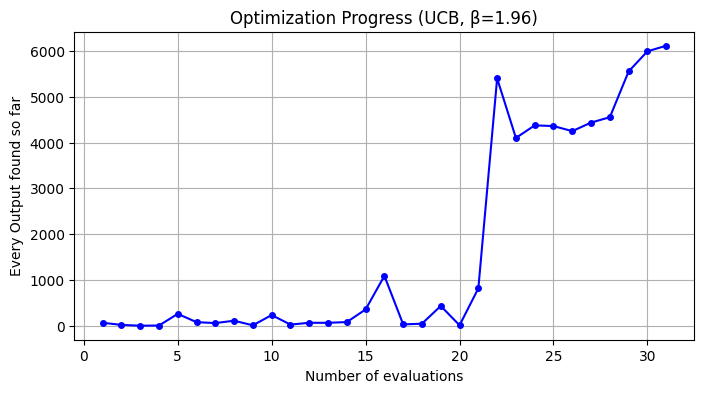

In [8]:
# 3. Load historical data and view current status
X, y = load_data()

print(f"Loaded {len(X)} points. And the historical OUTPUT:\n", y)

if len(y) > 0:
    previous_best = np.max(y)
    print(f"Current best output: {np.max(y):.6f}")
    plot_progress(X, y, beta)
else:
    print("Please load initial data")

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

Check whether the optimal output has been unimproved over several queries. If yes, execute the grid research function.

In [9]:
# 4. Recommend the next point to submit

trust_region = load_trust_region(X, y)
print(f"Trust region center: {trust_region['center']}, radius: {trust_region['radius']:.4f}")

if check_unimproved(y) & use_grid_search:
    print("Output has been unimproved over several queries. Use grid research for exploration.")
    x_next, best_acquisition_value = grid_search_acquisition(X, y, bounds, grid_density, acquisition_type)
    print(f"Grid search selected point with acquisition value: {best_acquisition_value:.6f}")
else:
    x_next, best_acquisition_value = suggest_next_point(X, y, trust_region, beta)
    print(f"GP selected point with acquisition value: {best_acquisition_value:.6f}")

submit_next = len(X) - len_init + 1
print(f"The {ordinal(submit_next)} recommended input point:")
print(np.round(x_next, 6))
print("-".join(map(str, np.round(x_next, 6))))

Trust region center: [0.99010435 0.8561887  0.99367421 0.98890734], radius: 0.1800
Use Upper Confidence Bound (UCB) acquisition function within Trust Region.
Predicted mean = 6332.687005, std = 82.044640, UCB = 6493.494500
GP selected point with acquisition value: 6493.494500
The 12th recommended input point:
[0.999731 0.963817 0.99248  0.916833]
0.999731-0.963817-0.99248-0.916833


In [ ]:
# 5. After obtaining the output from Capstone project portal, update the historical data

# Please manually enter the output value returned by Capstone project portal
y_new = float(input("Enter the output value returned by Capstone project portal: "))

# Append the new point to history
X = np.vstack([X, x_next])
y = np.append(y, y_new)

# Save updated data
save_data(X, y)
print("Historical data updated.")
print(f"There are {len(X)} points, and current best output: {np.max(y):.6f}")

plot_progress(X, y, beta)

# Update Trust Region
if np.max(y) > previous_best:
    improved = True
    print("Trust Region updated.")
else:
    improved = False
    print("Trust Region is not updated.")
best_X = X[np.argmax(y)]
update_trust_region(trust_region, best_X, improved)